# Deteção de Texto IA vs Humano — Regressão Logística

**Estratégia baseline** com representação TF-IDF e regressão logística em PyTorch.

**Classes alvo:** `Human`, `Google`, `Meta`, `OpenAI`, `Anthropic`

**Pipeline:**
```
Texto → Limpeza → TF-IDF → SimpleClassifier (Linear) → CrossEntropyLoss
```

## 1. Imports

In [57]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Configuração

In [ ]:
DATA_PATH   = "data/train.csv"
VAL_DATA_PATH = "data/test.csv"
TEXT_COL    = "Text"
LABEL_COL   = "Label"
TARGET_CLASSES = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]

MAX_WORDS   = 20000           # vocabulário TF-IDF 
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 0.001
TEST_SPLIT  = 0.1             # 10% do treino reservado para teste interno
SEED        = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED)

Device: cpu


## 3. Carregamento e Pré-processamento dos Dados

In [ ]:
def clean_text(text):
    """Limpeza básica do texto."""
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)       # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)    # mantém apenas letras
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Carregar CSVs
df_train = pd.read_csv(DATA_PATH, sep=";")
df_val = pd.read_csv(VAL_DATA_PATH)

available_labels_train = set(df_train[LABEL_COL].unique().tolist())
available_labels_val = set(df_val[LABEL_COL].unique().tolist())
if "Mistral" not in available_labels_train and "Anthropic" in available_labels_train:
    active_classes = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
else:
    active_classes = [c for c in TARGET_CLASSES if c in available_labels_train]

active_classes = [c for c in active_classes if c in available_labels_val]

N_CLASSES = len(active_classes)
df_train = df_train[df_train[LABEL_COL].isin(active_classes)].copy()
df_val = df_val[df_val[LABEL_COL].isin(active_classes)].copy()
print(f"Dataset treino shape: {df_train.shape}")
print(f"Dataset validação shape: {df_val.shape}")
print(f"\nDistribuição de classes (treino):")
print(df_train[LABEL_COL].value_counts())

# Limpeza do texto
df_train["clean_text"] = df_train[TEXT_COL].astype(str).apply(clean_text)
df_val["clean_text"] = df_val[TEXT_COL].astype(str).apply(clean_text)

# Codificar labels em inteiros (0..N-1)
le = LabelEncoder()
le.fit(active_classes)   # garante ordem consistente
df_train["label_enc"] = le.transform(df_train[LABEL_COL])
df_val["label_enc"] = le.transform(df_val[LABEL_COL])

print(f"\nMapeamento de classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
df_train.head(3)

[Aviso] Classe 'Mistral' não encontrada no dataset de treino. Usando 'Anthropic' como substituta temporária.
Dataset treino shape: (26500, 3)
Dataset validação shape: (225, 3)

Distribuição de classes (treino):
Label
Anthropic    5300
Google       5300
OpenAI       5300
Meta         5300
Human        5300
Name: count, dtype: int64

Mapeamento de classes: {np.str_('Anthropic'): np.int64(0), np.str_('Google'): np.int64(1), np.str_('Human'): np.int64(2), np.str_('Meta'): np.int64(3), np.str_('OpenAI'): np.int64(4)}


,ID,Text,Label,clean_text,label_enc
0,D1-1,"The human heart beats approximately 100,000 ti...",Anthropic,the human heart beats approximately times per day,0
1,D1-2,The Milky Way galaxy contains an estimated 100...,Anthropic,the milky way galaxy contains an estimated bil...,0
2,D1-3,Photosynthesis is the process by which plants ...,Anthropic,photosynthesis is the process by which plants ...,0


## 4. Divisão Treino / Validação / Teste

In [60]:
from sklearn.model_selection import train_test_split

texts_train_all = df_train["clean_text"].tolist()
labels_train_all = df_train["label_enc"].tolist()
texts_val = df_val["clean_text"].tolist()
labels_val = df_val["label_enc"].tolist()

# Separar teste interno apenas a partir do treino
texts_train, texts_test, labels_train, labels_test = train_test_split(
    texts_train_all, labels_train_all, test_size=TEST_SPLIT, random_state=SEED, stratify=labels_train_all
)

# Pesos por classe para reduzir impacto de desbalanceamento
train_counts = np.bincount(np.array(labels_train), minlength=N_CLASSES).astype(np.float32)
class_weights = train_counts.sum() / (N_CLASSES * np.maximum(train_counts, 1.0))
class_weights = class_weights / class_weights.mean()

print(f"Treino:    {len(texts_train):>5} exemplos")
print(f"Validação: {len(texts_val):>5} exemplos (dataset externo)")
print(f"Teste:     {len(texts_test):>5} exemplos")
print(f"Pesos por classe: {dict(zip(le.classes_, np.round(class_weights, 3)))}")

Treino:    23850 exemplos
Validação:   225 exemplos (dataset externo)
Teste:      2650 exemplos
Pesos por classe: {np.str_('Anthropic'): np.float32(1.0), np.str_('Google'): np.float32(1.0), np.str_('Human'): np.float32(1.0), np.str_('Meta'): np.float32(1.0), np.str_('OpenAI'): np.float32(1.0)}


## 5. Representação TF-IDF e Dataset PyTorch

In [61]:
# Fit do vectorizador apenas nos dados de treino (evita data leakage)
vectorizer = TfidfVectorizer(
    max_features=MAX_WORDS,
    ngram_range=(1, 2),       # unigramas + bigramas
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(texts_train).toarray()
X_val   = vectorizer.transform(texts_val).toarray()
X_test  = vectorizer.transform(texts_test).toarray()

print(f"Shape TF-IDF treino: {X_train.shape}")

Shape TF-IDF treino: (23850, 20000)


In [62]:
class TextDataset(Dataset):
    """Dataset genérico para features pré-computadas + labels inteiros (multiclasse)"""
    def __init__(self, X, labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)   # CrossEntropyLoss precisa de long

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TextDataset(X_train, labels_train)
val_dataset   = TextDataset(X_val,   labels_val)
test_dataset  = TextDataset(X_test,  labels_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

## 6. Modelo — Regressão Logística (SimpleClassifier)

In [63]:
class SimpleClassifier(nn.Module):
    """
    Regressão Logística Multiclasse.
    Uma única camada linear: input_dim → nclasses.
    (equivalente ao SimpleClassifier do imdb-torch-full.py, adaptado para multiclasse)
    """
    def __init__(self, input_dim, nclasses):
        super().__init__()
        self.linear = nn.Linear(input_dim, nclasses)

    def forward(self, x):
        return self.linear(x)   # logits — CrossEntropyLoss aplica softmax internamente


input_dim = X_train.shape[1]
model = SimpleClassifier(input_dim, N_CLASSES).to(device)
print(model)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters()):,}")

SimpleClassifier(
  (linear): Linear(in_features=20000, out_features=5, bias=True)
)

Parâmetros treináveis: 100,005


## 7. Treino e Avaliação

In [64]:
def evaluate(model, loader, criterion):
    """Calcula loss e accuracy num DataLoader — idêntico ao imdb-torch-full.py, adaptado para multiclasse"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)                          # logits: (B, nclasses)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)               # classe com maior logit
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total


def train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, verbose=True):
    """Loop de treino com class weights, scheduler e early stopping."""
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.03)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_loss = float("inf")
    bad_epochs = 0
    patience = 8

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader,   criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            bad_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping ativado na época {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [65]:
history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 01/30 | Train Loss: 1.5062 Acc: 0.6606 | Val Loss: 1.5732 Acc: 0.4178
Epoch 05/30 | Train Loss: 1.2065 Acc: 0.7832 | Val Loss: 1.4883 Acc: 0.4800
Epoch 10/30 | Train Loss: 0.9781 Acc: 0.8318 | Val Loss: 1.4789 Acc: 0.4889
Epoch 15/30 | Train Loss: 0.9104 Acc: 0.8466 | Val Loss: 1.4888 Acc: 0.4844
Early stopping ativado na época 15.


## 8. Curvas de Aprendizagem

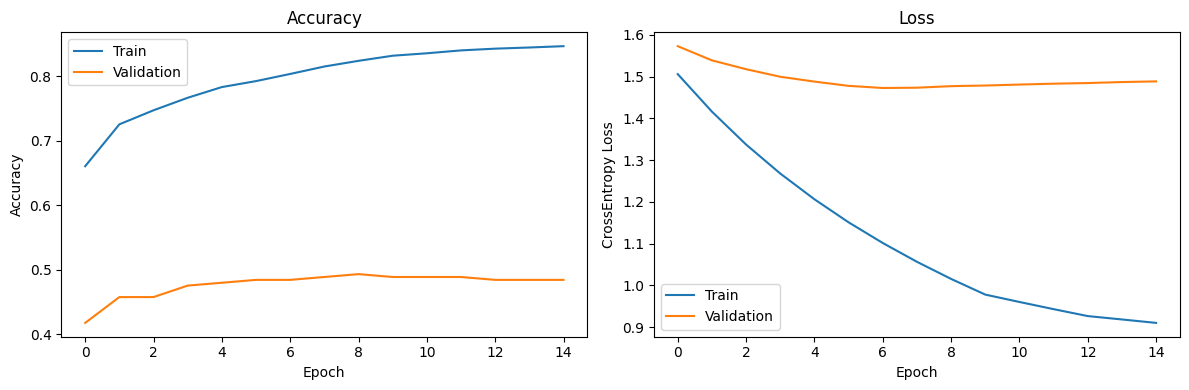

In [66]:
def plot_history(history):
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_acc"], label="Train")
    axes[0].plot(history["val_acc"],   label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train")
    axes[1].plot(history["val_loss"],   label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("CrossEntropy Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 9. Avaliação no Conjunto de Teste

In [67]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.2541
Test Accuracy: 0.5864


In [68]:
# Classification report por classe
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_class_indices = list(range(len(le.classes_)))
print(classification_report(
    all_labels,
    all_preds,
    labels=all_class_indices,
    target_names=le.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

   Anthropic       0.65      0.55      0.60       530
      Google       0.56      0.50      0.53       530
       Human       0.63      0.84      0.72       530
        Meta       0.57      0.51      0.54       530
      OpenAI       0.52      0.53      0.52       530

    accuracy                           0.59      2650
   macro avg       0.58      0.59      0.58      2650
weighted avg       0.58      0.59      0.58      2650



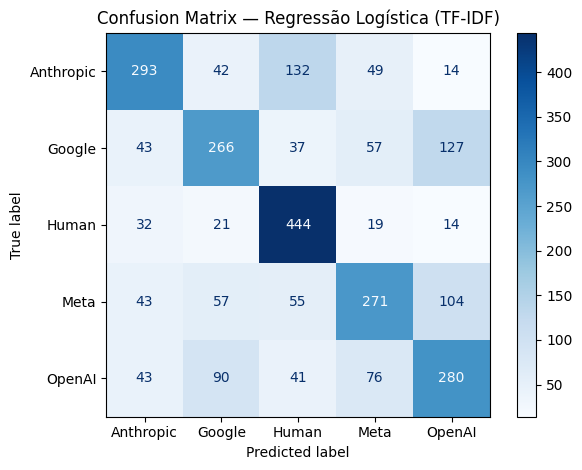

In [69]:
# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Regressão Logística (TF-IDF)")
plt.tight_layout()
plt.show()

## 10. Inferência — Classificar Novo Texto

In [70]:
def predict_text(text, model, vectorizer, label_encoder, device):
    """Classifica um texto novo e devolve a classe prevista e as probabilidades."""
    model.eval()
    cleaned = clean_text(text)
    x = vectorizer.transform([cleaned]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(x_tensor)              # (1, nclasses)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    print(f"Classe prevista: {label_encoder.classes_[pred]}")
    print("Probabilidades:")
    for cls, p in zip(label_encoder.classes_, probs):
        print(f"  {cls:12s}: {p:.4f}")
    return label_encoder.classes_[pred], probs


# Exemplo
sample = "The advancements in large language models have been remarkable over the past few years."
predict_text(sample, model, vectorizer, le, device)

Classe prevista: Human
Probabilidades:
  Anthropic   : 0.1809
  Google      : 0.2189
  Human       : 0.2834
  Meta        : 0.1512
  OpenAI      : 0.1656


(np.str_('Human'),
 array([0.18086997, 0.21893898, 0.28341278, 0.15120067, 0.1655776 ],
       dtype=float32))